In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

In [3]:
df = pd.read_csv(r"C:\Users\hp\Downloads\data scince\my project 2\data\customer_data.csv")

In [4]:
print("First 5 Rows")
print(df.head())

First 5 Rows
   Age  Income  Experience  Score  Purchase
0   56  109614          16     15         0
1   46  108116          33     47         0
2   32   76235          16     93         1
3   60   34855           3     25         0
4   25   56169          12      6         0


In [5]:
print("\nShape")
print(df.shape)


Shape
(10000, 5)


In [6]:
print("\nColumns")
print(df.columns)



Columns
Index(['Age', 'Income', 'Experience', 'Score', 'Purchase'], dtype='str')


In [7]:
print("\nInfo")
print(df.info())


Info
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Age         10000 non-null  int64
 1   Income      10000 non-null  int64
 2   Experience  10000 non-null  int64
 3   Score       10000 non-null  int64
 4   Purchase    10000 non-null  int64
dtypes: int64(5)
memory usage: 390.8 KB
None


In [8]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
Age           0
Income        0
Experience    0
Score         0
Purchase      0
dtype: int64


In [9]:
print("\nStatistical Summary")
print(df.describe())


Statistical Summary
                Age         Income    Experience         Score      Purchase
count  10000.000000   10000.000000  10000.000000  10000.000000  10000.000000
mean      41.054000   84427.786600     19.396000     50.345600      0.342600
std       13.484104   37782.070869     11.560508     28.707532      0.474603
min       18.000000   20002.000000      0.000000      1.000000      0.000000
25%       30.000000   51106.000000      9.000000     25.750000      0.000000
50%       41.000000   84381.000000     19.000000     50.000000      0.000000
75%       53.000000  116753.750000     30.000000     76.000000      1.000000
max       64.000000  149994.000000     39.000000     99.000000      1.000000


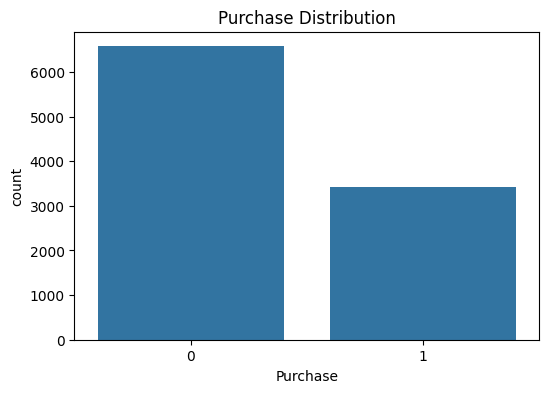

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Purchase', data=df)
plt.title("Purchase Distribution")
plt.show()

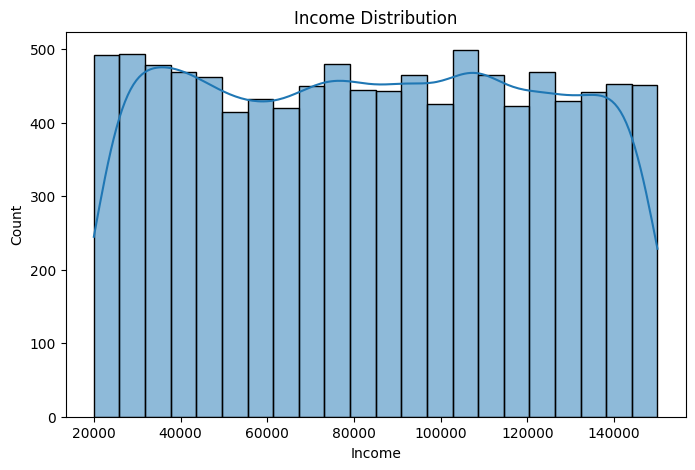

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Income"], kde=True)
plt.title("Income Distribution")
plt.show()

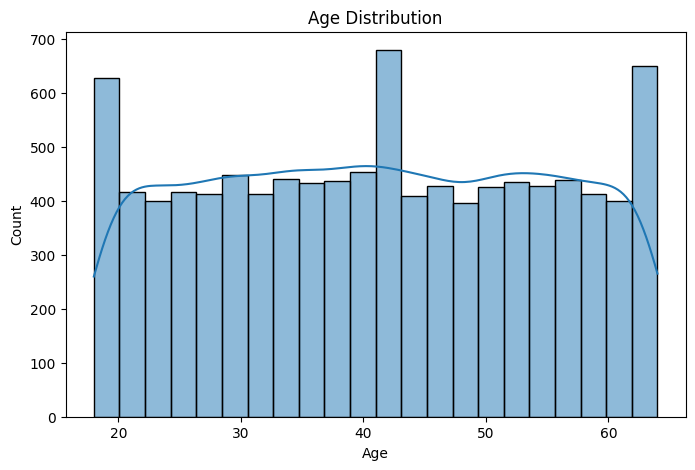

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()


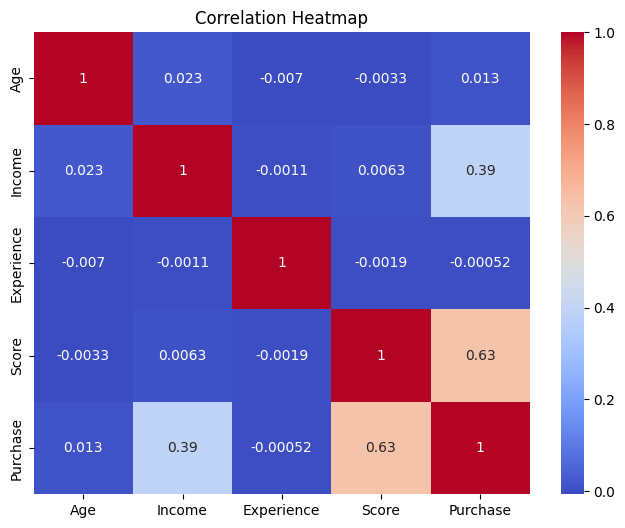

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
X = df.drop("Purchase", axis=1)
y = df["Purchase"]

In [15]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 4)
Target Shape: (10000,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [17]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8000, 4)
Testing Data: (2000, 4)


In [18]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [19]:

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [20]:
y_pred = model.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, y_pred)

In [22]:
print("\nAccuracy Score")
print(accuracy)



Accuracy Score
1.0


In [23]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))



Confusion Matrix
[[1340    0]
 [   0  660]]


In [24]:
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       1.00      1.00      1.00       660

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [25]:
joblib.dump(model, "model.pkl")

['model.pkl']

In [26]:
print("\nModel Saved Successfully")


Model Saved Successfully


In [27]:
sample_data = np.array([[25, 80000, 3, 70]])

In [28]:
prediction = model.predict(sample_data)

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [29]:
if prediction[0] == 1:
    print("Customer Will Purchase")
else:
    print("Customer Will Not Purchase")

Customer Will Purchase


In [30]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

In [31]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [32]:
print(feature_importance)


      Feature  Importance
3       Score    0.626044
1      Income    0.371641
0         Age    0.001319
2  Experience    0.000995


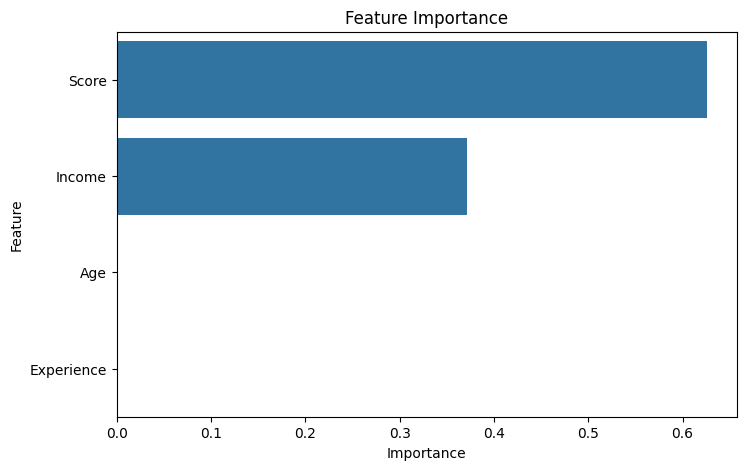

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)
plt.title("Feature Importance")
plt.show()